In [20]:
bar_data = [
    [0.019202, 0.023763, 0.000058, 0.000345],
    [0.038729, 0.047276, 0.000066, 0.001079],
    [0.056474, 0.068296, 0.000079, 0.002027],
    [0.117417, 0.139211, 0.000141, 0.004724],
]

/tmp/ipykernel_22240/4011157323.py:84: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, ymax*800 if ymax > 0 else 1.0)
/tmp/ipykernel_22240/4011157323.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.90))


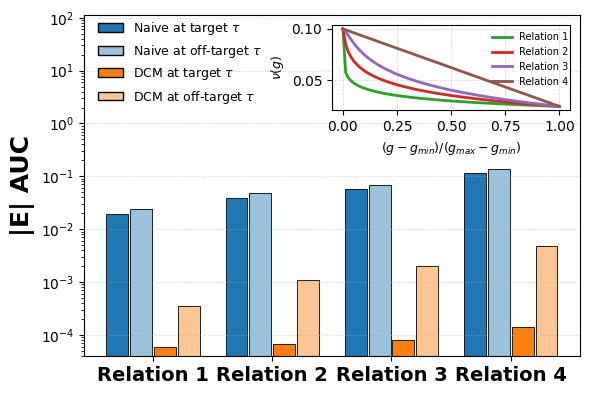

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

# --- Inputs expected ---
# bar_data: list/array with shape (N_relations, 4)
# relation_labels: optional list of length N_relations
# drift_curves: optional dict {relation_label: (coeff_array, rel_cond_array)}

# --- Fallback demo if not defined (safe to remove if you always pass them) ---
try:
    bar_data
except NameError:
    bar_data = [
        [0.012, 0.007, 0.020, 0.011],
        [0.015, 0.008, 0.023, 0.012],
        [0.011, 0.006, 0.019, 0.010],
        [0.014, 0.007, 0.022, 0.011],
    ]
try:
    relation_labels
except NameError:
    relation_labels = [f"Relation {i+1}" for i in range(len(bar_data))]
try:
    drift_curves
except NameError:
    drift_curves = None

bar_data = np.asarray(bar_data, dtype=float)
n_rel = bar_data.shape[0]
if relation_labels is None or len(relation_labels) != n_rel:
    relation_labels = [f"Rel-{i+1}" for i in range(n_rel)]

def lighten(color, factor=0.5):
    r, g, b = to_rgb(color)
    return tuple((1 - factor) * np.array([r, g, b]) + factor * np.array([1, 1, 1]))

cmap = plt.get_cmap("tab10")
# Colors for mapping types (bars)
color_naive      = cmap(0)  # base for Naive
color_dcm        = cmap(1)  # base for DCM
color_naive_off  = lighten(color_naive, 0.55)
color_dcm_off    = lighten(color_dcm, 0.55)

# Colors for relations (inset curves)
relation_colors = [cmap((2 + i) % 10) for i in range(n_rel)]

# ---------------- Figure & bars ----------------
fig, ax = plt.subplots(figsize=(6, 4.5))

indices = np.arange(n_rel)
group_width = 0.80
bar_width = group_width / 4.0

bar_labels = ["Naive @ target", "Naive @ off-target", "DCM @ target", "DCM @ off-target"]
bar_colors = [color_naive, color_naive_off, color_dcm, color_dcm_off]

containers = []
for j in range(4):
    x = indices - group_width/2 + (j + 0.5) * bar_width
    y = bar_data[:, j]
    bc = ax.bar(x, y, width=bar_width*0.92, color=bar_colors[j],
                edgecolor="black", linewidth=0.6)
    containers.append(bc)

ax.set_xticks(indices)
ax.set_xticklabels(relation_labels, fontsize=14, fontweight="bold")
ax.set_ylabel("|E| AUC", fontsize=18, fontweight="bold")
ax.grid(axis="y", linestyle=":", linewidth=0.7, alpha=0.6)
ax.set_yscale("log")

# Numeric labels (optional)
for bc in containers:
    for rect in bc:
        h = rect.get_height()
        # if np.isfinite(h):
        #     ax.text(rect.get_x() + rect.get_width()/2, h, f"{h:.1e}",
        #             ha="center", va="bottom", fontsize=8, clip_on=True)

# Y-limit with headroom
ymax = float(np.nanmax(bar_data)) if bar_data.size else 1.0
ax.set_ylim(0, ymax*800 if ymax > 0 else 1.0)

# ---------------- Inset (smaller) ----------------
# Tweak width/height to reduce/enlarge the inset size (percent of main axes)
axins = inset_axes(ax, width="48%", height="25%", loc="upper right", borderpad=0.7)
# axins.set_title("Drift coefficient vs relative conductance", fontsize=9, pad=6)

if isinstance(drift_curves, dict) and all(lbl in drift_curves for lbl in relation_labels):
    for lbl, col in zip(relation_labels, relation_colors):
        x, y = drift_curves[lbl]
        axins.plot(x, y, lw=2.0, color=col, label=lbl)
else:
    # Placeholder so inset isn't empty if no curves provided
    xd = np.linspace(0, 1.0, 80)
    for i, col in enumerate(relation_colors):
        if i == 0:
            yd = -0.0155 * np.log(xd ** 0.5 + 0.00762) + 0.0244
        if i == 1:
            yd = -0.0155 * np.log(xd ** 1.0 + 0.00762) + 0.0244
        if i == 2:
            yd = -0.0155 * np.log(xd ** 1.5 + 0.00762) + 0.0244
        if i == 3:
            yd = -0.0757 * xd + 0.1
        axins.plot(xd, yd, lw=2.0, color=col, label=relation_labels[i])

axins.set_xlabel(r"$(g-g_{min})/(g_{max}-g_{min})$", fontsize=9)
axins.set_ylabel(r"$\nu(g)$", fontsize=9)
axins.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
axins.legend(frameon=False, fontsize=7, loc="upper right", bbox_to_anchor=(1.03,1.02),  # x,y coords relative to axes
            )

# ---------------- Global legend for bars ----------------
bar_patches = [
    Patch(facecolor=color_naive, edgecolor="black", label=r"Naive at target $\tau$"),
    Patch(facecolor=color_naive_off, edgecolor="black", label=r"Naive at off-target $\tau$"),
    Patch(facecolor=color_dcm, edgecolor="black", label=r"DCM at target $\tau$"),
    Patch(facecolor=color_dcm_off, edgecolor="black", label=r"DCM at off-target $\tau$"),
]
# Leave a little room at the top for the legend
fig.tight_layout(rect=(0, 0, 1, 0.90))
# fig.legend(handles=bar_patches, loc="upper center", ncol=1,
#            frameon=False, fontsize=9, borderaxespad=0.2)
ax.legend(handles=bar_patches,
          loc="upper left",         # corner position
          bbox_to_anchor=(0.005,1.02),  # x,y coords relative to axes
          frameon=False,
          fontsize=9)
plt.savefig("drift_relation_dependency.png", dpi=300, bbox_inches='tight')

plt.show()
